In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

import numpy as np
import h5py
import sys
import os
sys.path.append('../src/')
# from density_profiles import read_density_profile  # Removed: function not found here

from density_profiles import empirical_density_profile
import pyEXP

In [4]:
def read_tng_halo_particles(filename):
    """
    Read halo particle coordinates and group properties from a TNG HDF5 file.

    The function automatically detects the halo ID contained in the key
    'galaxy_XXXXXX_ptldm_Coordinates'.

    Parameters
    ----------
    filename : str
        Path to HDF5 file.

    Returns
    -------
    coords : ndarray, shape (N,3)
        Dark matter particle positions [kpc].
    M200c : float
        Halo M200c mass.
    R200c : float
        Halo R200c radius.
    halo_id : str
        Halo ID string extracted from file.
    """
    mass_tng = 2.33443590182933*1e7

    with h5py.File(filename, 'r') as f:

        # Find coordinate key dynamically
        coord_key = None
        for key in f.keys():
            if key.startswith("galaxy_") and key.endswith("_ptldm_Coordinates"):
                coord_key = key
                break

        if coord_key is None:
            raise KeyError("No halo coordinate key found in file.")

        halo_id = coord_key.split('_')[1]

        coords = f[coord_key][:]
     
    marr = np.ones(len(coords)) * mass_tng
    return coords, marr 

In [5]:
snap=98
sim = "tng35-3-dark"
halo_subfind_id = 21537
snap_basename = "galaxies_halo_{subfind_id}_tng50-3-dark_{snap:03d}.hdf5"
input_snap = os.path.join("../data/", sim, snap_basename.format(subfind_id=halo_subfind_id, snap=snap))
coords, masses = read_tng_halo_particles(input_snap)
halo_data = {'pos' : coords, 'mass': masses}

In [9]:
r_s = 216.3
rho_s = 25463.891824026778

In [12]:
bin_edges = np.linspace(0, 400, 300)

r_b, rho_b = empirical_density_profile(bin_edges, halo_data['pos'], halo_data['mass'])
r_norm = r_b / r_s
rho_norm = rho_b / rho_s

bin_edges_norm = bin_edges / r_s
r_snap_norm, rho_snap_norm = empirical_density_profile(
    bin_edges_norm,
    halo_data['pos'] / r_s,
    halo_data['mass'] / (rho_s * r_s**3),
)

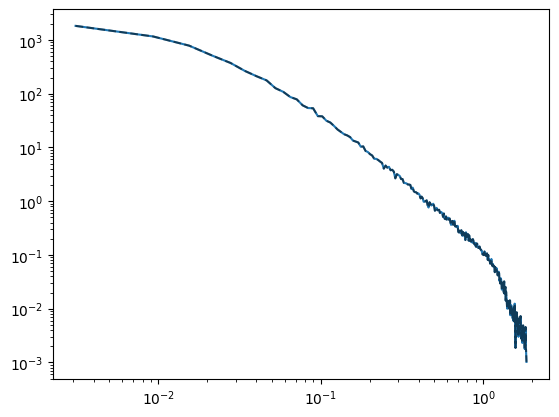

In [13]:
plt.loglog(r_norm, rho_norm)
plt.loglog(r_snap_norm, rho_snap_norm, c='k',ls='--', alpha=0.5)